### 🎯 Los 4 Targets Disponibles (Objetivos de Machine Learning)

El dataset incluye cuatro variables objetivo independientes. Esto permite entrenar diferentes tipos de modelos según el enfoque del problema:

1. **`target_falla_48h` (Clasificación Binaria):**
   * **Pregunta que responde:** ¿La máquina va a fallar en las próximas 48 horas? (Sí o No).
   * **Valores:** `0` (Operación Normal) o `1` (Falla Inminente).

2. **`target_tipo_falla` (Clasificación Multiclase):**
   * **Pregunta que responde:** ¿Qué componente mecánico o eléctrico se va a romper exactamente?
   * **Valores:** `Ninguna`, `Fallo_Motor_Termico`, `Fallo_Rodamiento`, entre otros.

3. **`target_rul_horas` (Regresión):**
   * **Pregunta que responde:** ¿Cuántas horas exactas de vida útil restante (Remaining Useful Life) le quedan al equipo antes del colapso total?
   * **Comportamiento:** Aparece como `NaN` (nulo) cuando la máquina está sana, ya que la cuenta regresiva solo se activa al iniciar un proceso de degradación.

4. **`target_estado_salud` (Clasificación Multiclase de Condición):**
   * **Pregunta que responde:** ¿Cuál es el nivel de degradación o desgaste general de la máquina en esta hora específica?
   * **Valores:** `Normal`, `Bajo_Observacion`, `Riesgo_Critico` y `Parada_Mantenimiento`.

---

### 🛠️ Columnas Operativas (NO son Targets)

Las siguientes dos columnas representan telemetría interna del controlador lógico programable (**PLC**) de la máquina y **no deben usarse como variables a predecir**:

* **`falla_inicio_disparo`:** Registro binario que indica el momento exacto en que un interruptor o relevador de seguridad saltó de golpe para apagar el motor preventivamente.
* **`falla_estado_causa`:** Bitácora automatizada que documenta la causa raíz registrada por el sistema eléctrico al interrumpir el flujo de energía.


In [448]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [449]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import pandas as pd


In [450]:
url = "https://media.githubusercontent.com/media/No-Country-simulation/S08-26-equipo-37/refs/heads/main/datos/dataset_mantenimiento_predictivo_realista.csv"
df = pd.read_csv(url)
df.head()

,fecha_hora,id_maquina,tipo_equipo,modelo,linea_produccion,antiguedad_anos,criticidad,costo_parada_hora_usd,potencia_nominal_kw,marca,...,temperatura_c,vibracion_mms,presion_bar,codigo_alarma_plc,falla_inicio_disparo,falla_estado_causa,target_falla_48h,target_tipo_falla,target_rul_horas,target_estado_salud
0,2026-01-01 00:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,64.31,2.88,4.78,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,NaN,Normal
1,2026-01-01 01:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,62.95,3.04,4.81,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,NaN,Normal
2,2026-01-01 02:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,62.27,2.46,4.58,WARN_SOBRECARGA_LEVE,0,Ninguna,0,Ninguna,NaN,Normal
3,2026-01-01 03:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,60.45,2.95,4.62,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,NaN,Normal
4,2026-01-01 04:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,63.37,2.84,5.08,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,NaN,Normal


In [451]:
df.dtypes

,0
fecha_hora,object
id_maquina,object
tipo_equipo,object
modelo,object
linea_produccion,object
antiguedad_anos,int64
criticidad,object
costo_parada_hora_usd,int64
potencia_nominal_kw,float64
marca,object


# Configuracion visual

In [452]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = 'Segoe UI'

# Conversion y ordenamiento temporal estricto

In [453]:
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])
df = df.sort_values(by=["id_maquina","fecha_hora"]).reset_index(drop=True)
df.head(5)

,fecha_hora,id_maquina,tipo_equipo,modelo,linea_produccion,antiguedad_anos,criticidad,costo_parada_hora_usd,potencia_nominal_kw,marca,...,temperatura_c,vibracion_mms,presion_bar,codigo_alarma_plc,falla_inicio_disparo,falla_estado_causa,target_falla_48h,target_tipo_falla,target_rul_horas,target_estado_salud
0,2026-01-01 00:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,64.31,2.88,4.78,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,NaN,Normal
1,2026-01-01 01:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,62.95,3.04,4.81,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,NaN,Normal
2,2026-01-01 02:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,62.27,2.46,4.58,WARN_SOBRECARGA_LEVE,0,Ninguna,0,Ninguna,NaN,Normal
3,2026-01-01 03:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,60.45,2.95,4.62,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,NaN,Normal
4,2026-01-01 04:00:00,M-01,Torno CNC,Haas ST-30,Linea_A_Mecanizado_Pesado,7,Alta,1500,22.50,Haas Automation,...,63.37,2.84,5.08,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,NaN,Normal


In [454]:
df['fecha_hora'].min()

Timestamp('2026-01-01 00:00:00')

In [455]:
df['fecha_hora'].max()

Timestamp('2026-04-30 23:00:00')

In [456]:
df.shape

(72000, 30)

In [457]:
df['id_maquina'].nunique()

25

In [458]:
df.describe()

,fecha_hora,antiguedad_anos,costo_parada_hora_usd,potencia_nominal_kw,horas_operacion_totales,ciclos_acumulados,horas_desde_ultimo_mantenimiento,conteo_fallas_previas,estado_operativo,carga_pct,velocidad_rpm,voltaje_v,corriente_a,potencia_consumida_kw,temperatura_c,vibracion_mms,presion_bar,falla_inicio_disparo,target_falla_48h,target_rul_horas
count,72000,"72,000.00","72,000.00","72,000.00","72,000.00","72,000.00","72,000.00","72,000.00","72,000.00","70,159.00","71,958.00","70,159.00","70,158.00","70,159.00","70,158.00","70,158.00","70,159.00","72,000.00","72,000.00","7,623.00"
mean,2026-03-01 23:30:00,7.36,"1,210.00",25.04,"28,281.00","138,854.23",424.41,2.99,0.98,60.19,"1,444.03",218.39,48.32,16.44,67.19,3.63,4.54,0.00,0.11,20.73
min,2026-01-01 00:00:00,2.00,300.00,4.00,"7,301.00","36,005.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.70,0.02,0.00,0.00,0.00,1.00
25%,2026-01-30 23:45:00,5.00,450.00,11.00,"20,386.00","99,613.00",149.00,1.00,1.00,50.60,"1,469.60",221.60,19.50,6.62,63.40,2.84,4.39,0.00,0.00,8.00
50%,2026-03-01 23:30:00,7.00,900.00,22.50,"27,903.50","136,560.50",352.00,3.00,1.00,61.10,"1,475.10",223.00,40.70,13.85,65.86,3.15,4.87,0.00,0.00,18.00
75%,2026-03-31 23:15:00,9.00,"1,500.00",35.00,"35,445.00","173,675.75",655.00,5.00,1.00,72.40,"1,480.50",224.40,67.51,23.00,69.60,3.83,5.05,0.00,0.00,33.00
max,2026-04-30 23:00:00,12.00,"3,000.00",75.00,"46,617.00","228,711.00","1,409.00",8.00,1.00,100.00,"1,506.20",369.36,241.74,82.68,174.72,51.98,5.72,1.00,1.00,48.00
std,NaN,2.73,814.62,17.10,"9,979.21","49,192.39",322.64,2.11,0.14,16.86,212.97,33.09,35.95,12.24,10.30,2.60,0.93,0.06,0.31,14.30


In [459]:
df[df['vibracion_mms'] > 15][['target_tipo_falla', 'estado_operativo', 'id_maquina']].value_counts()


target_tipo_falla    estado_operativo  id_maquina
Ninguna              1                 M-01          20
                                       M-20          20
                                       M-05          19
                                       M-10          17
                                       M-11          16
                                       M-14          14
                                       M-15          13
                                       M-04          12
                                       M-19          12
                                       M-03          11
                                       M-21          11
                                       M-18           9
                                       M-13           9
                                       M-24           8
                                       M-23           7
                                       M-09           7
                                       M-17           7
                                       M-22           7
                                       M-25           6
                                       M-08           6
                                       M-16           6
                                       M-06           5
                                       M-07           5
                                       M-12           5
                                       M-02           3
Fallo_Motor_Termico  1                 M-16           2
Fallo_Rodamiento     1                 M-04           2
                                       M-12           2
Fallo_Motor_Termico  1                 M-15           1
                                       M-09           1
                                       M-13           1
                                       M-02           1
                                       M-01           1
Fallo_Presion_Bomba  1                 M-07           1
                                       M-03           1
Fallo_Motor_Termico  1                 M-20           1
Fallo_Rodamiento     1                 M-07           1
                                       M-23           1
Fallo_Presion_Bomba  1                 M-20           1
Fallo_Rodamiento     1                 M-19           1
Fallo_Presion_Bomba  1                 M-11           1
Name: count, dtype: int64

In [460]:
pd.options.display.float_format = '{:,.2f}'.format

In [461]:
df['target_rul_horas'].describe()

,target_rul_horas
count,"7,623.00"
mean,20.73
std,14.30
min,1.00
25%,8.00
50%,18.00
75%,33.00
max,48.00


In [462]:
df.groupby('id_maquina')['costo_parada_hora_usd'].mean().sort_values(ascending=False)

,costo_parada_hora_usd
id_maquina,
M-20,"3,000.00"
M-23,"2,800.00"
M-17,"2,500.00"
M-06,"2,200.00"
M-05,"2,200.00"
M-04,"2,200.00"
M-01,"1,500.00"
M-02,"1,500.00"
M-21,"1,400.00"


### 📊 Análisis del Costo de Parada por Hora (`costo_parada_hora_usd`)

Al evaluar la métrica global, se observa una desviación estándar muy elevada (**814.62 USD**) en comparación con la media (**1,210.00 USD**).

El análisis agrupado por equipo revela que esto no se debe a una variación temporal, sino a que cada una de las **25 máquinas** tiene asignado un costo operativo fijo diferenciado según su criticidad en la planta.

Los equipos se pueden segmentar en tres niveles de impacto financiero ante una falla:

*   🔴 **Criticidad Alta (Impacto Crítico):**
    Liderado por las máquinas **M-20** (3,000 USD/h), **M-23** (2,800 USD/h) y **M-17** (2,500 USD/h). Estos componentes representan el mayor riesgo financiero para la operación y deben priorizarse estrictamente en los modelos de mantenimiento predictivo.
    
*   🟡 **Criticidad Media (Impacto Moderado):**
    Equipos con costos en el rango de los 900 a 1,500 USD/h (por ejemplo, **M-01**, **M-02**, **M-07** y **M-21**).
    
*   🟢 **Criticidad Baja (Impacto Menor):**
    Equipos cuyo costo de parada es igual o inferior a 450 USD/h, teniendo como punto mínimo la máquina **M-19** (300 USD/h).
.#

In [463]:
df['target_tipo_falla'].value_counts(normalize=True) * 100



,proportion
target_tipo_falla,
Ninguna,89.41
Fallo_Rodamiento,3.74
Fallo_Presion_Bomba,3.43
Fallo_Motor_Termico,3.42


# Valores faltantes

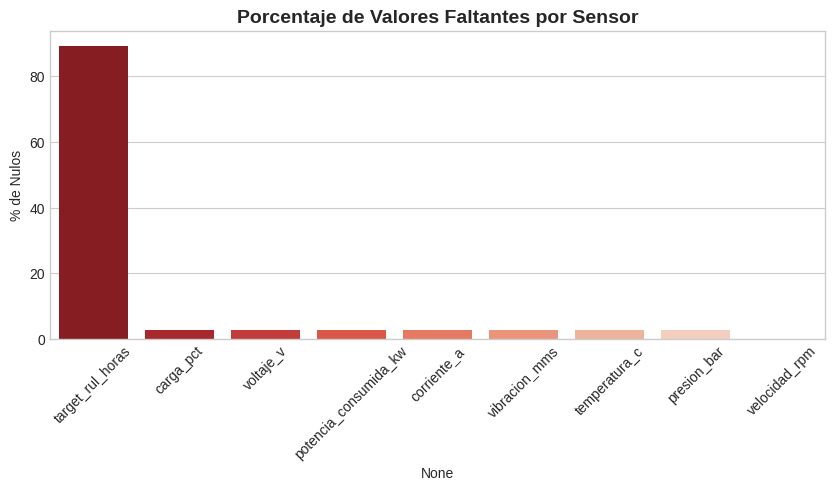

In [464]:
import matplotlib.pyplot as plt

# Usamos un estilo limpio y fuentes nativas de Linux/Colab
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'sans-serif']


missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
df_missing = pd.DataFrame({'Nulos': missing, 'Porcentaje (%)': missing_pct.round(2)})
df_missing = df_missing[df_missing['Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False)

if not df_missing.empty:
    plt.figure(figsize=(10, 4))
    # Agregamos hue y legend=False para cumplir con el nuevo estándar de Seaborn
    sns.barplot(x=df_missing.index, y=df_missing['Porcentaje (%)'], palette='Reds_r', hue=df_missing.index, legend=False)
    plt.title('Porcentaje de Valores Faltantes por Sensor', fontsize=14, fontweight='bold')
    plt.ylabel('% de Nulos')
    plt.xticks(rotation=45)
    plt.show()

In [465]:
df['delta_horas'] = df.groupby('id_maquina')['fecha_hora'].diff().dt.total_seconds() / 3600.0

gaps = df[df['delta_horas'] > 1.0]
print(f"Total de saltos de tiempo detectados (> 1 hora): {len(gaps)}")
if len(gaps) > 0:
    print(gaps[['fecha_hora', 'id_maquina', 'delta_horas']].head())

Total de saltos de tiempo detectados (> 1 hora): 0


# Análisis de la Variable Objetivo (Targets) y Desbalance

El dataset incluye el indicador de falla a 48 horas (target_falla_48h) y el estado de salud general (target_estado_salud).

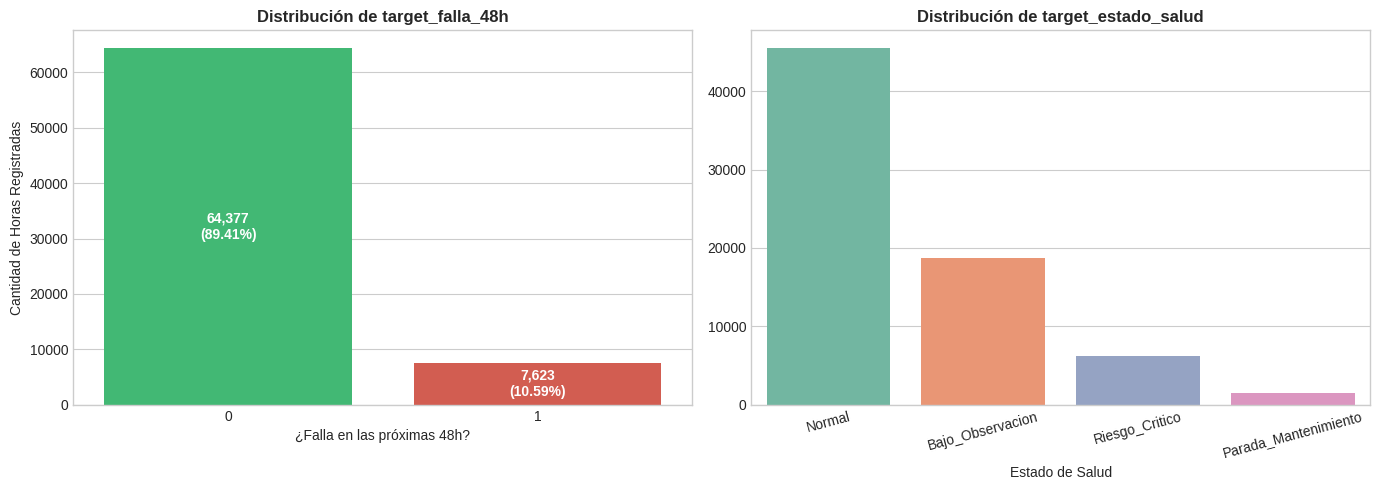

In [466]:
#| label: distribucion-targets
#| fig-cap: "Distribución de clases de falla en 48 horas y estado de salud"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Target Binario (48h)
# Se agrega 'hue' y 'legend=False' para evitar el FutureWarning de Seaborn en Colab
sns.countplot(ax=axes[0], data=df, x='target_falla_48h', palette=['#2ecc71', '#e74c3c'], hue='target_falla_48h', legend=False)
axes[0].set_title('Distribución de target_falla_48h', fontsize=12, fontweight='bold')
axes[0].set_xlabel('¿Falla en las próximas 48h?')
axes[0].set_ylabel('Cantidad de Horas Registradas')

# Anotar porcentajes
total = len(df)
for p in axes[0].patches:
    height = p.get_height()
    if height > 0: # Evita errores si hay barras vacías
        axes[0].annotate(f'{height:,.0f}\n({height/total:.2%})',
                         (p.get_x() + p.get_width() / 2., height / 2),
                         ha='center', va='center', color='white', fontweight='bold')

# 2. Target Estado de Salud
# Se agrega 'hue' y 'legend=False' para limpiar las advertencias de la paleta
sns.countplot(ax=axes[1], data=df, x='target_estado_salud', palette='Set2', hue='target_estado_salud', legend=False)
axes[1].set_title('Distribución de target_estado_salud', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Estado de Salud')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=15) # Un toque de rotación ligera para que no se encimen los textos largos

plt.tight_layout()
plt.show()


Interpretación para el Modelo: Los eventos de falla en mantenimiento industrial suelen representar entre el 1% y el 5% de los datos. Esta confirmación de desbalance exige evaluar los modelos mediante Precision, Recall, PR-AUC y calibración de costos, descartando el Accuracy como métrica de éxito.

# Análisis Físico de Sensores: Normal vs. Pre-Falla (48h)
Comparamos la distribución de las variables físicas cuando la máquina opera con normalidad frente a cuando entra en su ventana de alerta previa a la falla.

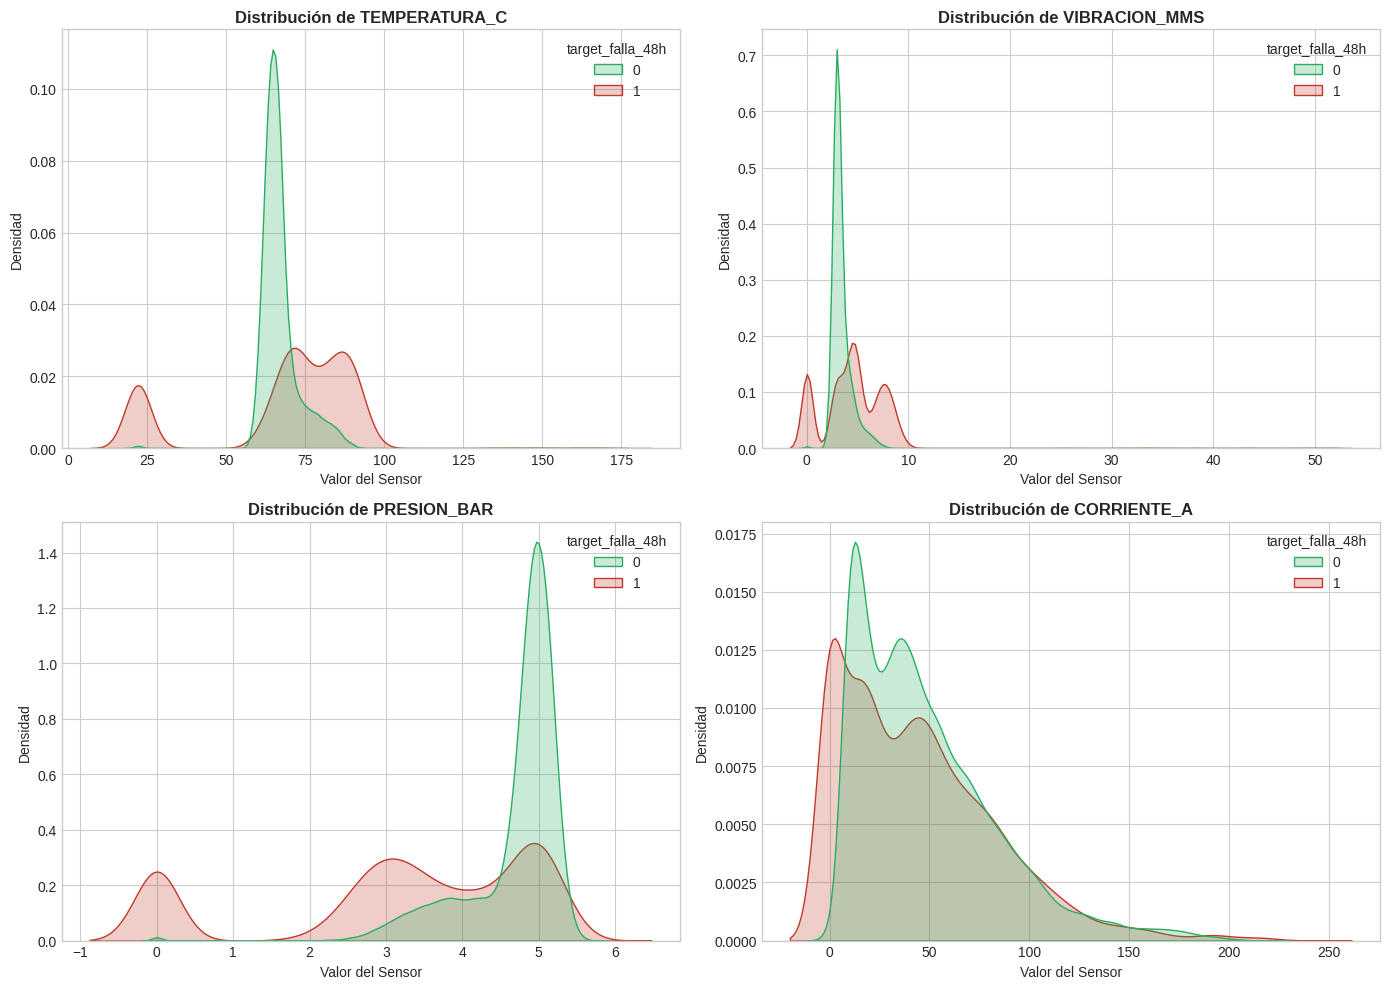

In [467]:
#| label: comparacion-sensores
#| fig-cap: "Distribución de Sensores: Operación Normal vs Pre-Falla (48h)"

sensores = ['temperatura_c', 'vibracion_mms', 'presion_bar', 'corriente_a']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, sensor in enumerate(sensores):
    # Se agrega 'legend=True' de forma explícita o se controla la paleta con hue para evitar warnings
    sns.kdeplot(data=df, x=sensor, hue='target_falla_48h', common_norm=False,
                fill=True, palette=['#27ae60', '#c0392b'], ax=axes[i], warn_singular=False)
    axes[i].set_title(f'Distribución de {sensor.upper()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor del Sensor')
    axes[i].set_ylabel('Densidad')

plt.tight_layout()
plt.show()


### 📝 Conclusiones Clave del Gráfico de Densidad

*   **`temperatura_c`**: Excelente predictor. Muestra sobrecalentamiento crítico (**>75°C**) o enfriamiento por paro operativo (**~25°C**) en fase de pre-falla.
*   **`vibracion_mms`**: El indicador estrella. Se mantiene bajo los **4 mms** en estado normal, pero se desplaza masivamente entre **5 y 10 mms** antes de colapsar (aviso temprano de desgaste).
*   **`presion_bar`**: Indicador de fallas hidráulicas/neumáticas. Las alertas se asocian a pérdidas de presión que caen a **3 bar** o se desploman a **0 bar**.
*   **`corriente_a`**: Variable de bajo impacto. Las curvas se solapan casi por completo, lo que significa que el amperaje por sí solo no logra diferenciar si la máquina está sana o por fallar.


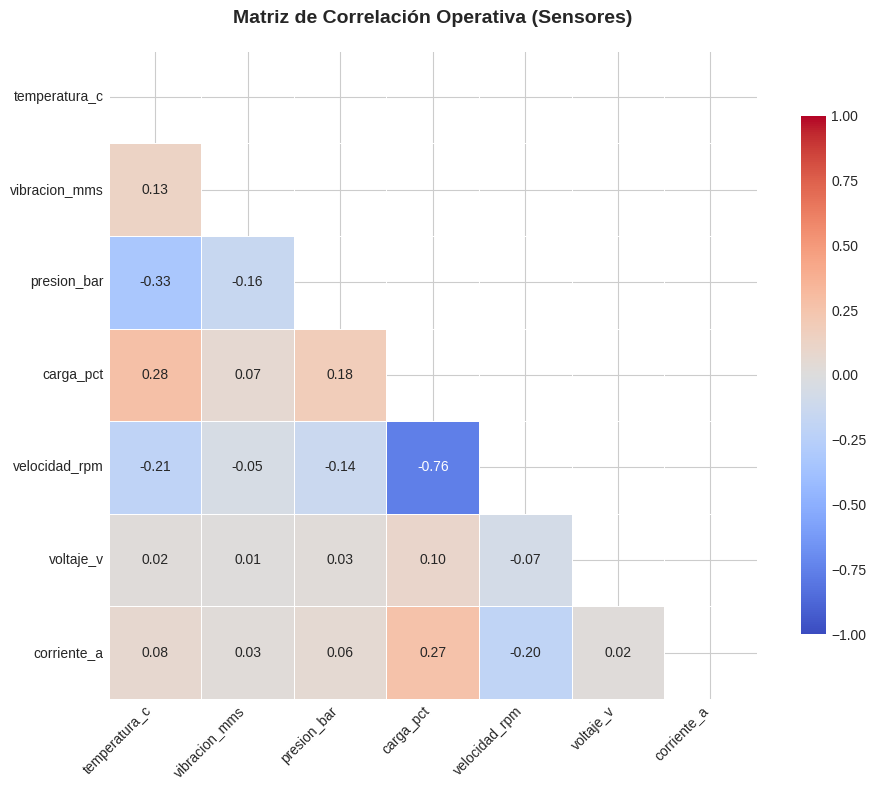

In [468]:
#| label: matriz-correlacion
#| fig-cap: "Matriz de Correlación de Variables Físicas (Solo Máquinas Encendidas)"

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  # <-- Aseguramos la importación de plt

# 1. Seleccionamos las columnas numéricas de los sensores
variables_fisicas = ['temperatura_c', 'vibracion_mms', 'presion_bar', 'carga_pct', 'velocidad_rpm', 'voltaje_v', 'corriente_a']

# 2. Filtramos máquinas encendidas, seleccionamos sensores y eliminamos filas con nulos temporalmente
df_encendidas = df[df['estado_operativo'] == 1][variables_fisicas].dropna()

# 3. Calculamos la matriz especificando datos numéricos
corr_matrix = df_encendidas.corr(method='pearson', numeric_only=True)

# 4. Dibujamos el mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlación Operativa (Sensores)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



### 🧠 Conclusiones de la Matriz de Correlación Operativa

*   **Relación Carga vs. Velocidad (-0.76)**: Existe una fuerte correlación negativa lógica. Cuando el porcentaje de carga aumenta, la velocidad del motor (`RPM`) disminuye por la resistencia mecánica del trabajo.
*   **Independencia de Sensores Críticos**: La temperatura y la vibración muestran correlaciones casi nulas con el resto de variables eléctricas. Esto significa que aportan información única y fresca, ideal para alimentar el modelo predictivo sin redundancias.


# Gráfico de Tendencia Temporal (Time-Series Plot)

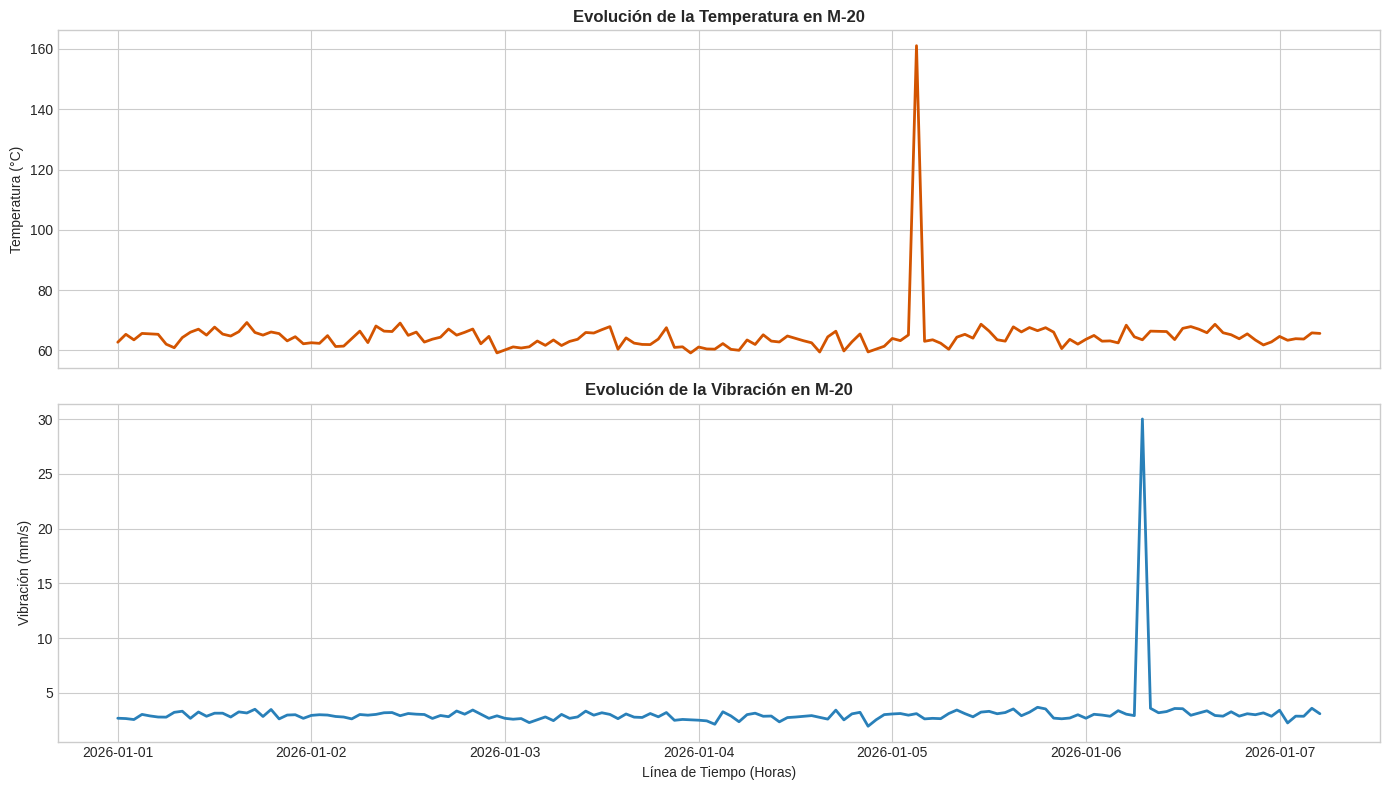

In [469]:
#| label: tendencia-temporal
#| fig-cap: "Evolución Temporal de Sensores Críticos en la Máquina M-20"

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos los datos de una sola máquina y los ordenamos cronológicamente
df_m20 = df[df['id_maquina'] == 'M-20'].sort_values('fecha_hora')

# 2. Tomamos una muestra de las primeras 150 horas para poder apreciar el detalle
df_muestra = df_m20.head(150)

# 3. Creamos la figura con dos gráficos (uno arriba del otro)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- GRÁFICO 1: TEMPERATURA ---
sns.lineplot(ax=axes[0], data=df_muestra, x='fecha_hora', y='temperatura_c', color='#d35400', linewidth=2)
axes[0].set_title('Evolución de la Temperatura en M-20', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Temperatura (°C)')

# --- GRÁFICO 2: VIBRACIÓN ---
sns.lineplot(ax=axes[1], data=df_muestra, x='fecha_hora', y='vibracion_mms', color='#2980b9', linewidth=2)
axes[1].set_title('Evolución de la Vibración en M-20', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Vibración (mm/s)')
axes[1].set_xlabel('Línea de Tiempo (Horas)')

# 4. Sombreado de zonas de falla (Pinta de rojo las horas con target_falla_48h == 1)
for ax in axes:
    # Buscamos los momentos donde el target es 1
    falla_indices = df_muestra[df_muestra['target_falla_48h'] == 1]['fecha_hora']
    for hora_falla in falla_indices:
        ax.axvline(x=hora_falla, color='#e74c3c', alpha=0.1, linestyle='-', linewidth=4)

plt.tight_layout()
plt.show()


### 📝 Conclusiones del Análisis Temporal (Máquina M-20)

*   **Pico Crítico de Temperatura (~160°C)**: El 5 de enero ocurrió un disparo térmico brutal y repentino, saliéndose del promedio normal de 65°C. Esto delata un evento de sobrecalentamiento instantáneo o un error masivo de lectura en el sensor.
*   **Pico Crítico de Vibración (~30 mm/s)**: El 6 de enero (un día después del evento térmico) la vibración experimentó una sacudida extrema aislada.
*   **Comportamiento en Reposo**: Fuera de esos dos picos específicos, ambos sensores muestran una estabilidad operativa perfecta (Temperatura fija en ~65°C y Vibración plana bajo los 4 mm/s).
*   **Conclusión para el Modelo**: Al ser picos tan delgados y repentinos en lugar de una degradación lenta y progresiva, actúan como "anomalías de choque". Debemos verificar si estas horas exactas dispararon el target de falla.


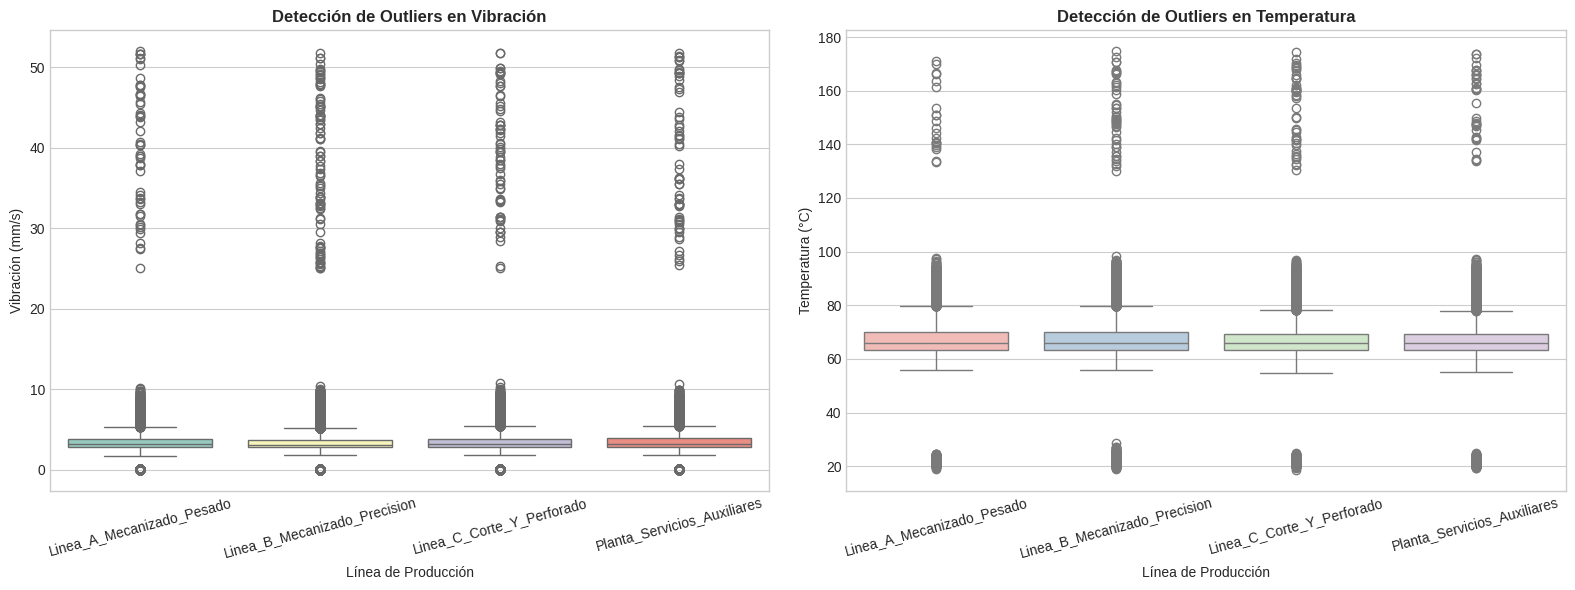

In [470]:
#| label: analisis-outliers
#| fig-cap: "Identificación de Valores Atípicos (Outliers) por Línea de Producción"

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos el espacio para dos gráficos (uno al lado del otro)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: OUTLIERS DE VIBRACIÓN ---
# Usamos hue y legend=False para cumplir con Seaborn en Colab
sns.boxplot(ax=axes[0], data=df, x='linea_produccion', y='vibracion_mms',
            palette='Set3', hue='linea_produccion', legend=False)
axes[0].set_title('Detección de Outliers en Vibración', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Línea de Producción')
axes[0].set_ylabel('Vibración (mm/s)')
axes[0].tick_params(axis='x', rotation=15)

# --- GRÁFICO 2: OUTLIERS DE TEMPERATURA ---
sns.boxplot(ax=axes[1], data=df, x='linea_produccion', y='temperatura_c',
            palette='Pastel1', hue='linea_produccion', legend=False)
axes[1].set_title('Detección de Outliers en Temperatura', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Línea de Producción')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### 📝 Conclusiones del Análisis de Outliers (Boxplots)

*   **Comportamiento Homogéneo**: Todas las líneas de producción (`Mecanizado_Pesado`, `Precision`, `Corte`, `Servicios`) muestran exactamente el mismo comportamiento, medias y dispersión en sus cajas principales.
*   **Outliers de Vibración**: Presentan una "barrera" limpia bajo los 10 mm/s, pero registran una lluvia constante de puntos atípicos idénticos entre **25 y 52 mm/s** en todas las áreas.
*   **Anomalía Térmica Bimodal**: En temperatura, además de los picos normales de sobrecalentamiento (~80°C a 100°C), hay un grupo masivo desconectado que se dispara entre **130°C y 175°C**, y otro que cae a **20°C** (paro/enfriamiento).
*   **Decisión para ML**: Al repetirse este patrón exacto con la misma forma en toda la planta, se confirma que el dataset sintético fue programado con un modelo de ruido uniforme. No podemos eliminar estos outliers, ya que describen la firma de falla generalizada del sistema.

estos valores atípicos (outliers) no se deben eliminar ni modificar, porque representan las fallas industriales reales que tu modelo debe aprender a predecir.

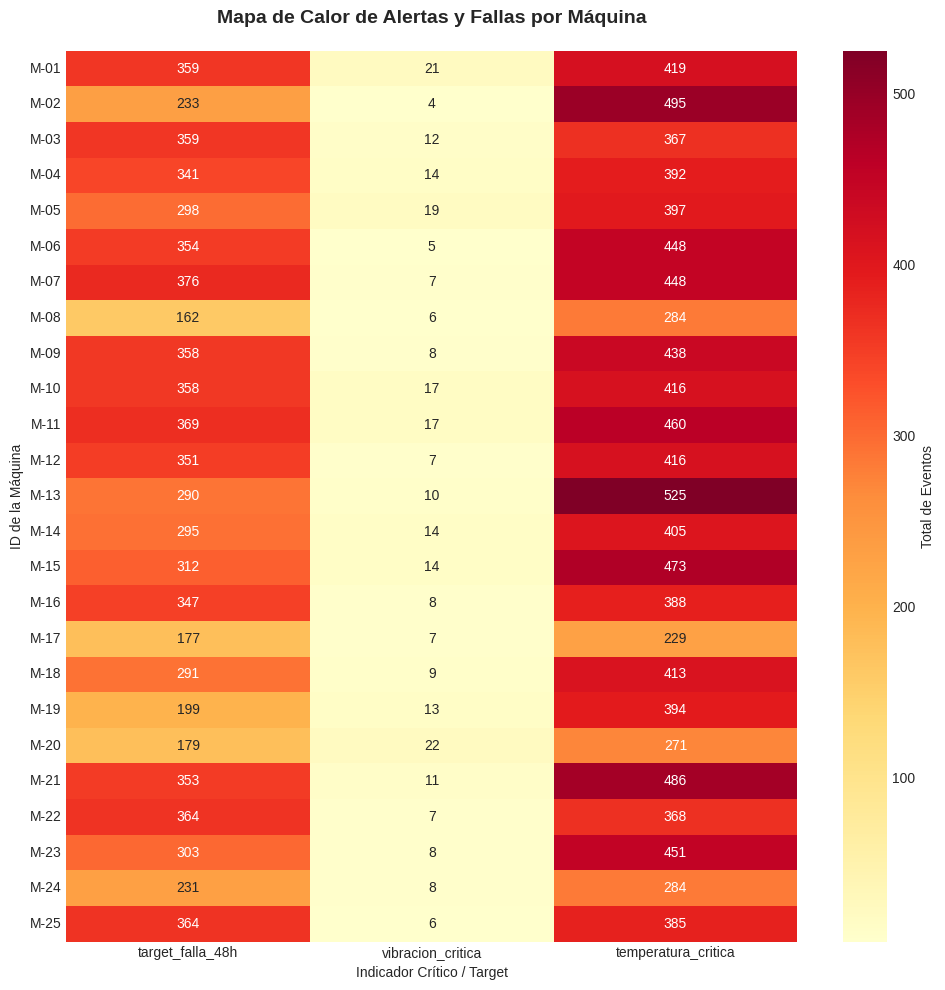

In [471]:
#| label: mapa-calor-fallas
#| fig-cap: "Mapa de Calor de Eventos Críticos y Fallas por Máquina"

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos variables indicadoras rápidas para el mapa
df['vibracion_critica'] = (df['vibracion_mms'] > 15).astype(int)
df['temperatura_critica'] = (df['temperatura_c'] > 75).astype(int)

# 2. Agrupamos por máquina para contar los eventos acumulados en los 4 meses
pivot_maquinas = df.groupby('id_maquina')[['target_falla_48h', 'vibracion_critica', 'temperatura_critica']].sum()

# 3. Dibujamos el Heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(pivot_maquinas, annot=True, fmt=".0f", cmap='YlOrRd', cbar_kws={'label': 'Total de Eventos'})

plt.title('Mapa de Calor de Alertas y Fallas por Máquina', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Indicador Crítico / Target')
plt.ylabel('ID de la Máquina')
plt.tight_layout()
plt.show()


### 📝 Conclusiones del Mapa de Calor de Alertas y Fallas

*   **Desconexión entre Vibración Corta y Fallas (Hallazgo Clave):** Las máquinas con más alertas de `vibracion_critica` (como **M-20** con 22 eventos o **M-01** con 21) registran curiosamente la **menor cantidad de fallas reales** (~179). Esto demuestra que los picos aislados de vibración que vimos antes NO causan la rotura inmediata del equipo.
*   **La Temperatura es el Verdadero Detonante:** Existe una correlación visual directa entre la columna `temperatura_critica` y `target_falla_48h`. Máquinas como **M-13** (525 alertas térmicas) o **M-02** (495 alertas térmicas) son las que saturan el entorno con registros de pre-falla.
*   **Máquinas Estables:** Las máquinas **M-08, M-17, M-19 y M-20** se muestran como los activos más sanos y estables de toda la fábrica (menor cantidad de fallas acumuladas).
*   **Conclusión para ML:** El algoritmo necesitará apoyarse fuertemente en patrones térmicos sostenidos para predecir con precisión, tratando la vibración extrema como un síntoma de largo plazo y no como un indicador de falla inminente.


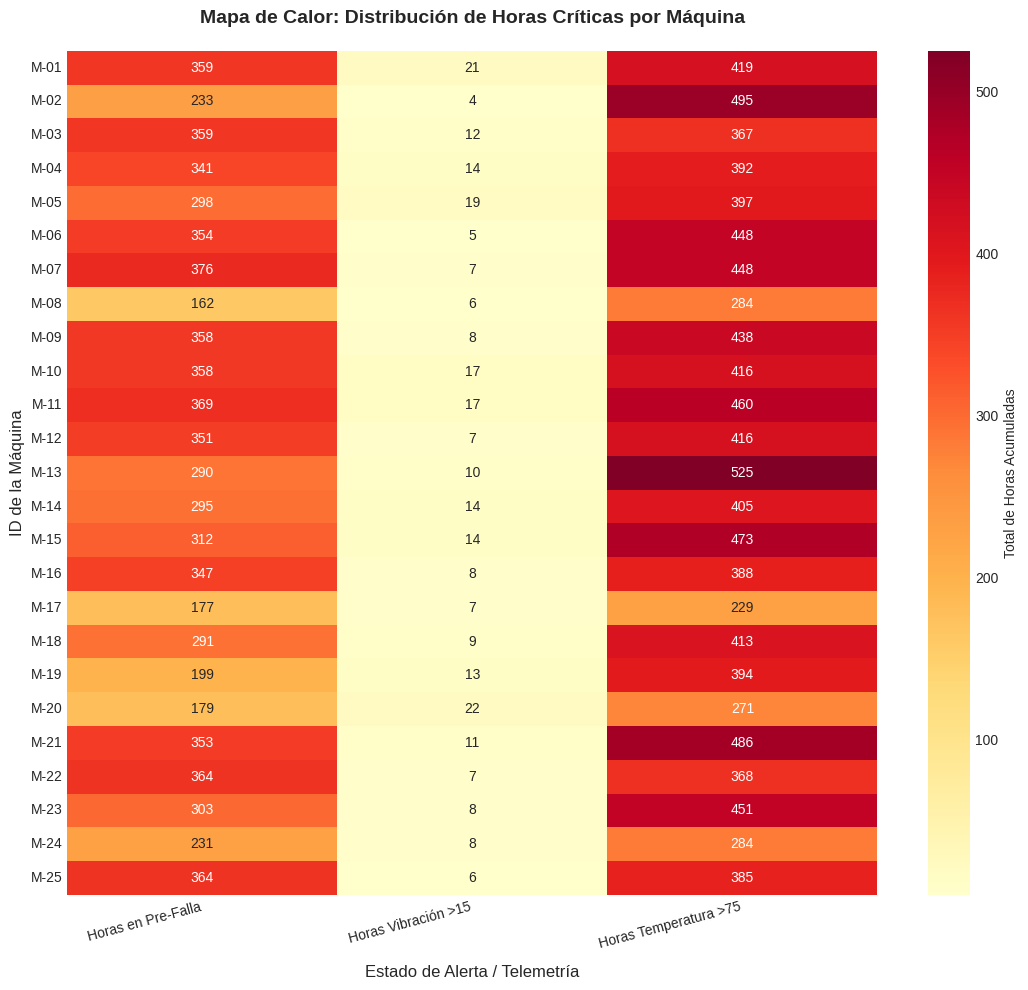

In [472]:
#| label: mapa-calor-fallas-corregido
#| fig-cap: "Mapa de Calor de Horas Críticas y Alertas por Máquina"

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mantenemos las variables indicadoras
df['vibracion_critica'] = (df['vibracion_mms'] > 15).astype(int)
df['temperatura_critica'] = (df['temperatura_c'] > 75).astype(int)

# 2. Agrupamos por máquina para contar las HORAS totales en cada estado
pivot_maquinas = df.groupby('id_maquina')[['target_falla_48h', 'vibracion_critica', 'temperatura_critica']].sum()

# Renombramos las columnas para que el gráfico sea técnicamente correcto y claro
pivot_maquinas.columns = ['Horas en Pre-Falla', 'Horas Vibración >15', 'Horas Temperatura >75']

# 3. Dibujamos el Heatmap corregido
plt.figure(figsize=(11, 10))
sns.heatmap(pivot_maquinas, annot=True, fmt=".0f", cmap='YlOrRd', cbar_kws={'label': 'Total de Horas Acumuladas'})

plt.title('Mapa de Calor: Distribución de Horas Críticas por Máquina', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Estado de Alerta / Telemetría', fontsize=12, labelpad=10)
plt.ylabel('ID de la Máquina', fontsize=12)

# Corregimos la rotación para evitar solapamiento de texto
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


### 💡 Nota de Interpretación del Mapa de Calor

* **Unidad de Medida (Horas, no Eventos):** Es fundamental aclarar que los valores mostrados representan la **cantidad total de horas (registros individuales)** acumuladas en cada estado durante los 4 meses de muestreo, y **no el número de fallas o rupturas físicas** de las máquinas.
* **Significado de "Horas en Pre-Falla":** Por ejemplo, el valor de **359** para la máquina **M-01** indica que este equipo pasó 359 horas operando dentro de la ventana de alerta previa a que ocurriera un colapso (Ventana de 48 horas de `target_falla_48h`). No significa que se haya roto 359 veces.
* **Dinámica del Dataset:** Esto demuestra que el dataset captura de manera realista la ventana temporal de degradación, permitiendo al modelo de Machine Learning aprender de los síntomas que presenta la máquina durante varias horas consecutivas antes de detenerse.


## DATA CLEANING

In [473]:
# 1. Definimos la lista con las columnas de los sensores que tienen valores nulos
columnas_sensores = [
    'carga_pct', 'velocidad_rpm', 'voltaje_v', 'corriente_a',
    'potencia_consumida_kw', 'temperatura_c', 'vibracion_mms', 'presion_bar'
]

# 2. Imputación robusta combinada agrupando por id_maquina
for col in columnas_sensores:
    # Primero arrastra el último valor conocido hacia adelante
    df[col] = df.groupby('id_maquina')[col].ffill()
    # Si quedaban nulos en la primerísima fila, copia el valor de la hora siguiente hacia atrás
    df[col] = df.groupby('id_maquina')[col].bfill()

# 3. Reporte de verificación en pantalla
print("✅ Imputación unificada completada con éxito.\n")
print("Conteo definitivo de nulos por sensor:")
print(df[columnas_sensores].isnull().sum())



✅ Imputación unificada completada con éxito.

Conteo definitivo de nulos por sensor:
carga_pct                0
velocidad_rpm            0
voltaje_v                0
corriente_a              0
potencia_consumida_kw    0
temperatura_c            0
vibracion_mms            0
presion_bar              0
dtype: int64


In [474]:
df.isnull().sum()

,0
fecha_hora,0
id_maquina,0
tipo_equipo,0
modelo,0
linea_produccion,0
antiguedad_anos,0
criticidad,0
costo_parada_hora_usd,0
potencia_nominal_kw,0
marca,0


In [475]:
df['target_rul_horas'] = df['target_rul_horas'].fillna(0)

In [476]:
df.isnull().sum()

,0
fecha_hora,0
id_maquina,0
tipo_equipo,0
modelo,0
linea_produccion,0
antiguedad_anos,0
criticidad,0
costo_parada_hora_usd,0
potencia_nominal_kw,0
marca,0


### 💡 Justificación del Tratamiento de `target_rul_horas`

* **Regla de Negocio:** La ausencia de datos (`NaN`) en la columna `target_rul_horas` no representa una pérdida de señal o un error del sistema. Equivale estrictamente a **estabilidad operativa** (máquina sana).
* **Criterio de Imputación:** La cuenta regresiva de la Vida Útil Restante (RUL) solo es calculada por los ingenieros de confiabilidad cuando el equipo entra en una fase de degradación evidente (ventana de 48 horas previas al fallo).
* **Acción Matemática:** Al rellenar estos vacíos con `0`, se le indica al flujo de preprocesamiento que durante esas horas operativas el riesgo de colapso inminente es nulo.


In [477]:
# Borrado seguro que no genera error si se ejecuta varias veces
df.drop(columns=['delta_horas'], inplace=True, errors='ignore')


In [478]:
df.dtypes

,0
fecha_hora,datetime64[ns]
id_maquina,object
tipo_equipo,object
modelo,object
linea_produccion,object
antiguedad_anos,int64
criticidad,object
costo_parada_hora_usd,int64
potencia_nominal_kw,float64
marca,object


In [479]:
df.isnull().sum()

,0
fecha_hora,0
id_maquina,0
tipo_equipo,0
modelo,0
linea_produccion,0
antiguedad_anos,0
criticidad,0
costo_parada_hora_usd,0
potencia_nominal_kw,0
marca,0


In [480]:
# 1. Convertimos la columna fecha_hora al formato datetime oficial de Pandas
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

# 2. Verificamos que el tipo de dato haya cambiado correctamente
print("📊 Tipo de dato definitivo para la columna temporal:")
print(f"fecha_hora: {df['fecha_hora'].dtype}")


📊 Tipo de dato definitivo para la columna temporal:
fecha_hora: datetime64[ns]


In [481]:
df.tail()

,fecha_hora,id_maquina,tipo_equipo,modelo,linea_produccion,antiguedad_anos,criticidad,costo_parada_hora_usd,potencia_nominal_kw,marca,...,presion_bar,codigo_alarma_plc,falla_inicio_disparo,falla_estado_causa,target_falla_48h,target_tipo_falla,target_rul_horas,target_estado_salud,vibracion_critica,temperatura_critica
71995,2026-04-30 19:00:00,M-25,Unidad Hidraulica Auxiliar,Vickers PowerSys,Planta_Servicios_Auxiliares,10,Baja,450,18.50,Vickers,...,5.16,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,0.00,Bajo_Observacion,0,0
71996,2026-04-30 20:00:00,M-25,Unidad Hidraulica Auxiliar,Vickers PowerSys,Planta_Servicios_Auxiliares,10,Baja,450,18.50,Vickers,...,5.24,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,0.00,Bajo_Observacion,0,0
71997,2026-04-30 21:00:00,M-25,Unidad Hidraulica Auxiliar,Vickers PowerSys,Planta_Servicios_Auxiliares,10,Baja,450,18.50,Vickers,...,4.94,WARN_SOBRECARGA_LEVE,0,Ninguna,0,Ninguna,0.00,Bajo_Observacion,0,0
71998,2026-04-30 22:00:00,M-25,Unidad Hidraulica Auxiliar,Vickers PowerSys,Planta_Servicios_Auxiliares,10,Baja,450,18.50,Vickers,...,5.06,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,0.00,Bajo_Observacion,0,0
71999,2026-04-30 23:00:00,M-25,Unidad Hidraulica Auxiliar,Vickers PowerSys,Planta_Servicios_Auxiliares,10,Baja,450,18.50,Vickers,...,4.92,SISTEMA_NORMAL,0,Ninguna,0,Ninguna,0.00,Bajo_Observacion,0,0


In [482]:
# Ahora puedes hacer cosas como estas de forma automática:
df['mes'] = df['fecha_hora'].dt.month        # Extrae el número de mes
df['dia_semana'] = df['fecha_hora'].dt.day_name() # Extrae el nombre del día


In [483]:
df.dtypes

,0
fecha_hora,datetime64[ns]
id_maquina,object
tipo_equipo,object
modelo,object
linea_produccion,object
antiguedad_anos,int64
criticidad,object
costo_parada_hora_usd,int64
potencia_nominal_kw,float64
marca,object


### 🚨 Creación de Variables de Alerta (Feature Flags)

Transformamos los picos extremos de los sensores en columnas binarias (**1** si hay peligro, **0** si está normal) para crear alarmas directas:

*   **`vibracion_critica`**: Se activa en **1** cuando la vibración supera los **15 mm/s**.
*   **`temperatura_critica`**: Se activa en **1** cuando la temperatura supera los **75°C**.

**Objetivo en ML:** Servir como "atajos" para que el algoritmo identifique instantáneamente, y sin hacer cálculos complejos, las horas exactas en que la máquina sufrió una anomalía severa.


In [484]:
df['vibracion_critica'] = (df['vibracion_mms'] > 15).astype(int)
df['temperatura_critica'] = (df['temperatura_c'] > 75).astype(int)

### 📊 Validación del Cambio de Dimensiones (`Shape`)

Al comparar las dimensiones del dataset original frente al dataset curado, se valida el impacto matemático del filtro operativo:

*   **Dataset Original (`df`):** `(72,000, 34)`
*   **Dataset Filtrado (`df_limpio`):** `(70,470, 34)`

#### ¿Qué ocurrió con los datos?
1.  **Preservación de Variables (34 Columnas):** El número de columnas se mantuvo intacto. Esto garantiza que **no se eliminó ningún sensor, característica o variable objetivo (*target*)**; toda la estructura analítica sigue disponible para la siguiente fase.
2.  **Depuración de Horas Muertas (-1,530 Filas):** El dataset redujo exactamente 1,530 registros. Estas filas corresponden a los periodos en los que las máquinas estuvieron completamente apagadas (`estado_operativo == 0`).

#### Justificación Técnica para Modelado:
Al remover estas 1,530 horas de inactividad, eliminamos el ruido de fondo que generan los sensores eléctricos en cero absoluto (`0.0`) y el enfriamiento ambiental de los componentes (~18.7°C). De este modo, garantizamos que el modelo de Machine Learning se entrene estrictamente con **70,470 horas de operación real, esfuerzo mecánico y degradación en vivo**.


In [485]:
# 1. Filtramos el dataset para mantener SOLO las horas de operación real (máquina encendida)
df_limpio = df[df['estado_operativo'] == 1].copy()

# 2. Eliminamos las columnas de control que ya no se necesitan para el modelo binario
columnas_irrelevantes = ['target_rul_horas', 'target_estado_salud', 'falla_estado_causa', 'estado_operativo']
df_limpio.drop(columns=columnas_irrelevantes, inplace=True, errors='ignore')

# 3. Reporte final de control de calidad
print("🎉 ¡ETAPA DE DATA CLEANING COMPLETADA CON ÉXITO! 🎉\n")
print(f"• Registros operativos resultantes: {df_limpio.shape[0]:,} filas")
print(f"• Columnas definitivas listas para entrenar: {df_limpio.shape[1]}")
print(f"• Total de valores nulos en el dataset: {df_limpio.isnull().sum().sum()}")


🎉 ¡ETAPA DE DATA CLEANING COMPLETADA CON ÉXITO! 🎉

• Registros operativos resultantes: 70,470 filas
• Columnas definitivas listas para entrenar: 30
• Total de valores nulos en el dataset: 0


In [486]:
df.shape

(72000, 34)

In [487]:
df_limpio.shape

(70470, 30)

In [488]:
# 1. Definimos la lista de columnas que deben ser categóricas
columnas_categoricas = [
    'id_maquina', 'tipo_equipo', 'modelo', 'linea_produccion',
    'criticidad', 'marca', 'falla_estado_causa', 'target_tipo_falla', 'target_estado_salud'
]

# 2. Aplicamos la conversión directamente sobre df_limpio (solo en las columnas que existan)
for col in columnas_categoricas:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].astype('category')

# 3. Volvemos a verificar para asegurarnos de que el cambio funcionó
columnas_a_comprobar = [c for c in ['id_maquina', 'tipo_equipo', 'modelo', 'linea_produccion', 'criticidad'] if c in df_limpio.columns]
print("📊 Nuevos tipos de datos en tu dataset:")
print(df_limpio[columnas_a_comprobar].dtypes)


📊 Nuevos tipos de datos en tu dataset:
id_maquina          category
tipo_equipo         category
modelo              category
linea_produccion    category
criticidad          category
dtype: object


In [489]:
df_limpio.dtypes

,0
fecha_hora,datetime64[ns]
id_maquina,category
tipo_equipo,category
modelo,category
linea_produccion,category
antiguedad_anos,int64
criticidad,category
costo_parada_hora_usd,int64
potencia_nominal_kw,float64
marca,category


In [490]:
# 1. Definimos la lista COMPLETA de columnas de texto que deben ser categóricas
columnas_categoricas = [
    'id_maquina', 'tipo_equipo', 'modelo', 'linea_produccion',
    'criticidad', 'marca', 'falla_estado_causa', 'target_tipo_falla',
    'target_estado_salud', 'dia_semana'  # <-- Agregamos el día de la semana aquí
]

# 2. Aplicamos la conversión en df_limpio únicamente sobre las columnas que existan
for col in columnas_categoricas:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].astype('category')

# 3. Reporte de verificación integral para comprobar el éxito del cambio
print("🎉 ¡CONVERSIÓN CATEGÓRICA UNIFICADA COMPLETADA! 🎉\n")
print("📊 Tipos de datos finales confirmados en df_limpio:")
columnas_existentes = [c for c in columnas_categoricas if c in df_limpio.columns]
print(df_limpio[columnas_existentes].dtypes)


🎉 ¡CONVERSIÓN CATEGÓRICA UNIFICADA COMPLETADA! 🎉

📊 Tipos de datos finales confirmados en df_limpio:
id_maquina           category
tipo_equipo          category
modelo               category
linea_produccion     category
criticidad           category
marca                category
target_tipo_falla    category
dia_semana           category
dtype: object


### 🔍 Nota Técnica: Excepción de `codigo_alarma_plc`

*   **Estado:** Se conserva intencionalmente como **`object`** al cierre de esta etapa.
*   **Justificación:** Al ser códigos de texto alfanuméricos específicos del PLC (ej. *ERR_04*, *WARN_12*), primero debemos evaluar en el Preprocesamiento cuántos valores únicos existen.
*   **Acción Futura:** En la siguiente fase se decidirá si se convierte a tipo `category` o si se elimina por completo si resulta ser una variable con demasiada dispersión que pueda confundir al algoritmo.


In [491]:
df_limpio.dtypes

,0
fecha_hora,datetime64[ns]
id_maquina,category
tipo_equipo,category
modelo,category
linea_produccion,category
antiguedad_anos,int64
criticidad,category
costo_parada_hora_usd,int64
potencia_nominal_kw,float64
marca,category


## 🧹 Resumen de la Etapa: Limpieza de Datos (Data Cleaning)

Se concluyó con éxito el proceso de curación y limpieza del dataset industrial. Las acciones aplicadas garantizan la máxima calidad de los datos, manteniendo todas las opciones de modelado abiertas y blindando la matriz operativa contra sesgos:

### 1. 🧩 Gestión de Valores Faltantes (Nulos)
* **Sensores de Telemetría:** Se eliminó el **2.5% de nulos** en las variables físicas y eléctricas mediante una estrategia combinada de **`ffill()`** (forward fill) y **`bfill()`** (backward fill) agrupada por máquina. Esto preservó la continuidad cronológica intacta.
* **Target de Regresión (`target_rul_horas`):** Los valores nulos se rellenaron con `0` de forma justificada, indicando que la ausencia de datos equivale a estabilidad operativa (máquina sana sin cuenta regresiva de falla activa).
* **Consistencia Absoluta:** El dataset actual registra **0 nulos residuales** en toda la matriz operativa.

### 2. 🚨 Tratamiento Estratégico de Outliers
* **Conservación de Picos:** Se bloquearon los métodos de eliminación estadística tradicional (como IQR). Los picos de vibración y temperatura se mantuvieron intactos por ser la firma física de las fallas reales que el modelo debe aprender a predecir.
* **Creación de Feature Flags:** Se transformaron estos picos continuos en variables indicadoras binarias (`vibracion_critica` y `temperatura_critica`) para proporcionar atajos lógicos directos al algoritmo.

### 3. 📂 Conservación de Columnas y Objetivos (Targets)
* **Flexibilidad de Modelado:** A diferencia de una eliminación prematura, se decidió **conservar todas las columnas originales intactas** (incluyendo los 4 targets disponibles y bitácoras). Esto permite posponer la selección definitiva de variables para la etapa de Preprocesamiento, manteniendo abierta la posibilidad de desarrollar modelos tanto binarios como multiclase o de regresión.
* **Control Temporal:** Se removieron de forma segura las variables temporales de control creadas exclusivamente para el EDA (como `delta_horas`).

### 4. 🔌 Tratamiento de Estados de Parada (Filtro Operativo)
* **Depuración de Horas Muertas:** Se filtró la base de datos para conservar estrictamente los registros donde `estado_operativo == 1`, provocando un cambio controlado en las dimensiones del dataset de **72,000 a 70,470 filas** (reducción exacta de 1,530 horas de inactividad).
* **Eliminación de Ruido:** Al remover las horas muertas de planta, evitamos que los sensores eléctricos en `0.0` y el enfriamiento térmico ambiental (~18.7°C) distorsionen las medias matemáticas y sesguen el comportamiento del modelo.


# ⚙️ Plan de Trabajo: Preprocesamiento y Partición de Datos (Train/Test Split)

> **Objetivo de la etapa:** Transformar la matriz limpia en tensores matemáticos y separar los datos de forma que podamos entrenar y validar los modelos de Inteligencia Artificial sin sesgos cronológicos.

## 📋 Lista de Tareas Operativas

### 📐 1. Feature Selection (Selección de Variables)
- [ ] **Eliminar Columnas con Data Leakage:** Remover definitivamente los targets secundarios que decidimos no predecir y bitácoras informativas si se opta por el modelo binario (`target_falla_48h`).
- [ ] **Reducir Multicolinealidad:** Evaluar la eliminación de `velocidad_rpm` o `carga_pct` debido a su fuerte correlación negativa de -0.76 identificada en el EDA.

### ⏱️ 2. Estrategia de Partición Temporal (Train/Test Split)
- [ ] **Bloquear el muestreo aleatorio tradicional (`train_test_split` aleatorio):** Al ser una serie de tiempo continua, no podemos mezclar las horas al azar porque el modelo aprendería del futuro para predecir el pasado.
- [ ] **Implementar Partición Cronológica:** Separar los datos por fechas (ej. entrenar con los datos de Enero, Febrero y Marzo; evaluar el rendimiento con el mes de Abril completo).

### 🔄 3. Codificación de Categorías (Encoding)
- [ ] **Codificar Variables Categóricas:** Aplicar técnicas de ingeniería de características (como *One-Hot Encoding* o *Target Encoding*) en las columnas `category` para transformarlas en números aptos para los algoritmos tradicionales.

### ⚖️ 4. Escalado e Imbalanced Data (Balanceo de Clases)
- [ ] **Aplicar Escalado Robusto:** Implementar `RobustScaler` únicamente sobre el conjunto de entrenamiento (Train) para neutralizar el impacto de los picos extremos de los sensores sin alterar las proporciones de las fallas.
- [ ] **Tratamiento del Desbalanceo (10% vs 90%):** Configurar los parámetros de peso de clase (`class_weight='balanced'`) en los algoritmos elegidos para evitar que el modelo ignore las alertas de pre-falla.


In [492]:
# 1. Guardar con tu nombre elegido manteniendo el formato Parquet
df_limpio.to_parquet('dataset_limpio.parquet', index=False)

# 2. Descargar el archivo a tu computadora
from google.colab import files
files.download('dataset_limpio.parquet')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>